# Netflix Movies and TV Shows Data Analysis

This project analyzes Netflix movies and TV shows using Python, Pandas, and Matplotlib.

## 1. Problem Space

Netflix has a large catalog of movies and TV shows from many countries, genres, ratings, and release years. This project studies Netflix content to understand what types of titles are most common, how content has changed over time, and what patterns appear in the dataset.

This matters because viewers, media companies, and streaming platforms can use this type of analysis to understand entertainment trends.

## 2. Dataset Description

The dataset used is the Netflix Movies and TV Shows dataset from Kaggle. It includes information such as title, type, director, cast, country, date added, release year, rating, duration, and genre.

## 3. Questions to Address

1. How many movies and TV shows are in the dataset?
2. Which countries produce the most Netflix content?
3. What are the most common ratings?
4. What are the most common genres?
5. How has Netflix content changed over release years?
6. Which directors appear most often?
7. What is the distribution of movie durations?
8. Which release years have the most titles?

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [27]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [28]:
df.shape

(8807, 12)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


## 4. Data Cleaning

In [30]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [31]:
df_clean = df.copy()

columns_to_fill = ["country", "director", "cast", "rating", "duration", "date_added"]

for col in columns_to_fill:
    df_clean[col] = df_clean[col].fillna("Unknown")

df_clean.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Missing values were replaced with "Unknown" so the analysis could keep most rows instead of deleting a large amount of data.

## 5. Exploratory Data Analysis

In [32]:
df_clean.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,8807,8807,8807,8807,8807.000000,8807,8807,8807,8807
unique,8807,2,8807,4529,7693,749,1768,NaN,18,221,514,8775
top,s1,Movie,Dick Johnson Is Dead,Unknown,Unknown,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,2634,825,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [33]:
df_clean["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [34]:
df_clean["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

## 6. Analysis and Answers

### Question 1: How many movies and TV shows are in the dataset?

In [35]:
type_counts = df_clean["type"].value_counts()
type_counts

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

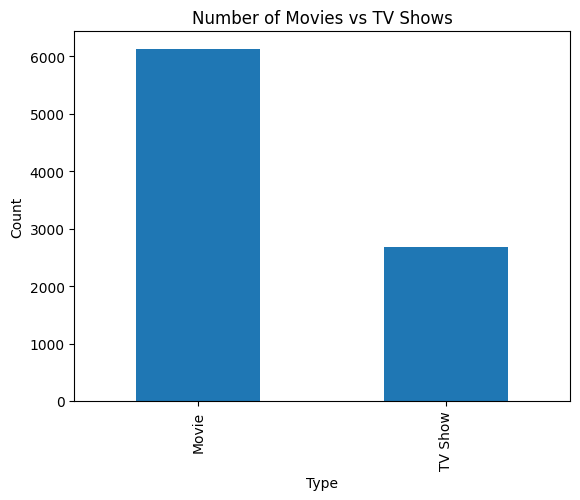

In [36]:
type_counts.plot(kind="bar")
plt.title("Number of Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

The dataset contains more movies than TV shows, showing that Netflix's catalog in this dataset is more movie-focused.

### Question 2: Which countries produce the most Netflix content?

In [37]:
top_countries = df_clean[df_clean["country"] != "Unknown"]["country"].value_counts().head(10)
top_countries

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

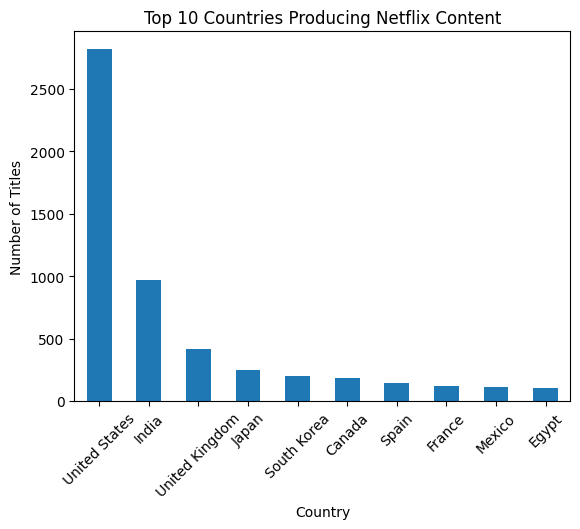

In [38]:
top_countries.plot(kind="bar")
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

The countries with the most Netflix content are major entertainment markets, with the United States usually appearing as the largest contributor.

### Question 3: What are the most common ratings?

In [39]:
top_ratings = df_clean[df_clean["rating"] != "Unknown"]["rating"].value_counts().head(10)
top_ratings

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

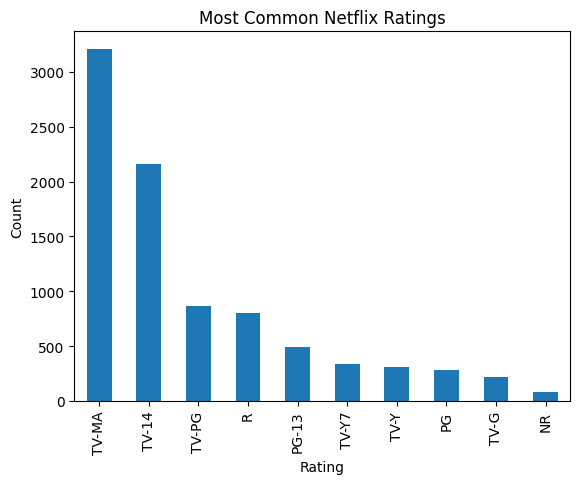

In [40]:
top_ratings.plot(kind="bar")
plt.title("Most Common Netflix Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

The most common ratings show the main audience groups Netflix content is targeted toward.

### Question 4: What are the most common genres?

In [41]:
genres = df_clean["listed_in"].str.split(", ").explode()
top_genres = genres.value_counts().head(10)
top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

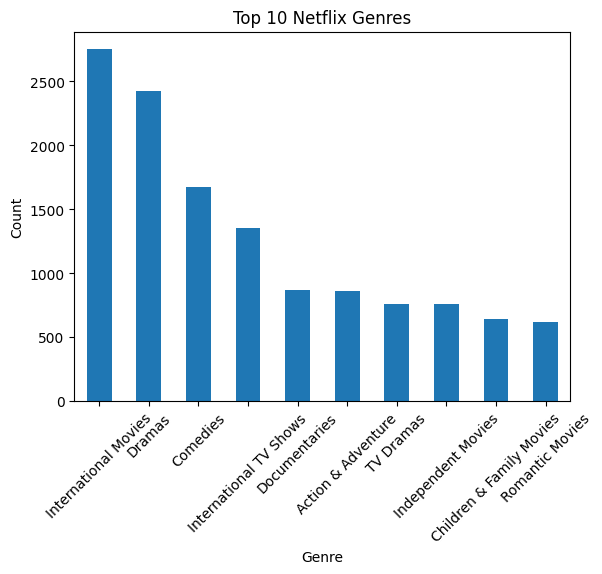

In [42]:
top_genres.plot(kind="bar")
plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The most common genres show what types of content appear most frequently on Netflix.

### Question 5: How has Netflix content changed over release years?

In [43]:
titles_by_year = df_clean["release_year"].value_counts().sort_index()
titles_by_year.tail(20)

release_year
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

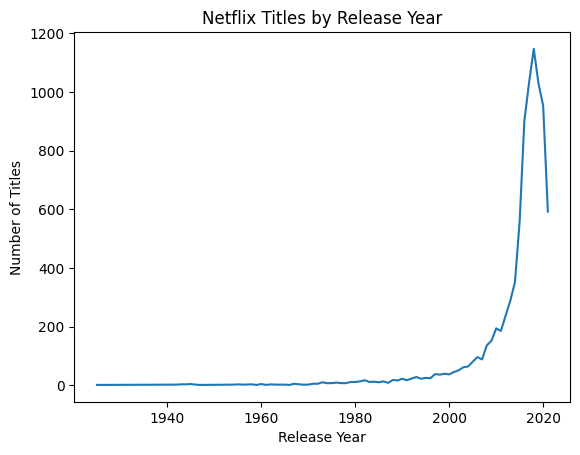

In [44]:
titles_by_year.plot(kind="line")
plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

The number of Netflix titles is higher in recent years, showing that the dataset contains more modern content.

### Question 6: Which directors appear most often?

In [45]:
top_directors = df_clean[df_clean["director"] != "Unknown"]["director"].value_counts().head(10)
top_directors

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

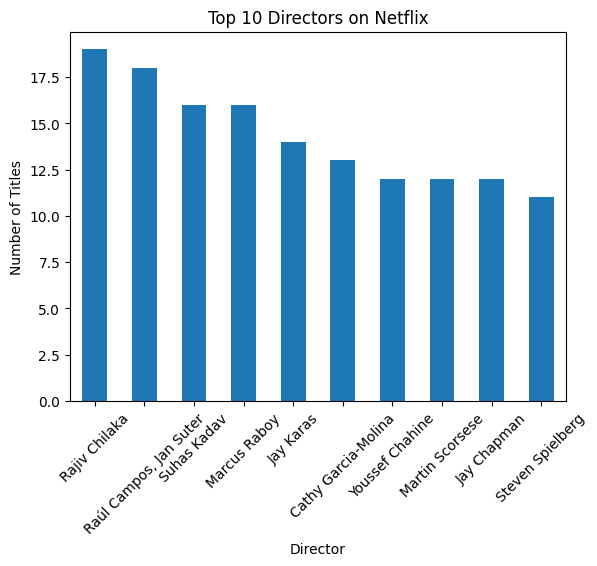

In [46]:
top_directors.plot(kind="bar")
plt.title("Top 10 Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

Some directors appear multiple times, suggesting they have a larger presence in Netflix's catalog.

### Question 7: What is the distribution of movie durations?

In [47]:
movies = df_clean[df_clean["type"] == "Movie"].copy()

movies["duration_minutes"] = movies["duration"].str.replace(" min", "", regex=False)
movies["duration_minutes"] = pd.to_numeric(movies["duration_minutes"], errors="coerce")

movies["duration_minutes"].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

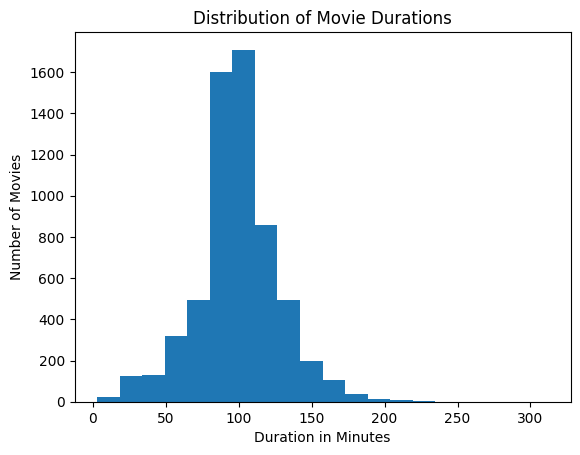

In [48]:
movies["duration_minutes"].dropna().plot(kind="hist", bins=20)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration in Minutes")
plt.ylabel("Number of Movies")
plt.show()

Most movies fall within a standard feature-length runtime, while very short and very long movies are less common.

### Question 8: Which release years have the most titles?

In [49]:
top_release_years = df_clean["release_year"].value_counts().head(10)
top_release_years

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

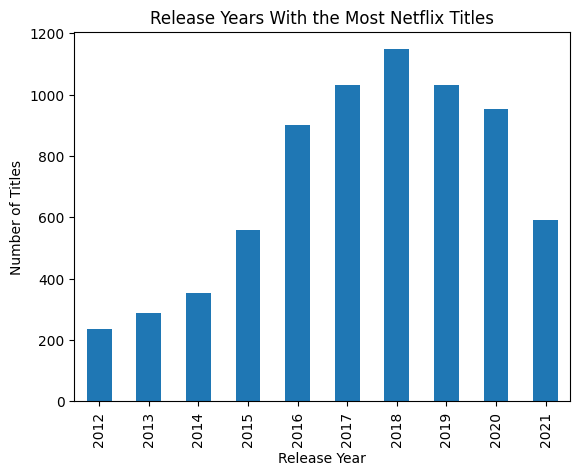

In [50]:
top_release_years.sort_index().plot(kind="bar")
plt.title("Release Years With the Most Netflix Titles")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

The years with the most titles are mostly recent years, showing that Netflix has a strong focus on modern content.

## 7. Insights and Conclusion

This analysis shows that Netflix has more movies than TV shows in this dataset. The United States and other major entertainment markets produce many of the titles. The most common genres and ratings show that Netflix offers content for a wide range of viewers.

The release year analysis shows that many Netflix titles come from recent years. Movie duration analysis also shows that most films follow standard feature-length runtimes.

Ultimately, the dataset shows that Netflix's catalog is diverse, international, and heavily focused on recent movies and shows.